In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

In [ ]:
# ── Model definitions ────────────────────────────────────────────────────────
models = [
    ("ACE-Bi",        "eval_results_ACE.csv",       "eval_forces_ACE.npz"),
    ("GRACE-2L-Bi",   "eval_results_GRACE_UPF.csv", "eval_forces_GRACE_UPF.npz"),
    ("GRACE-2L-OMAT", "eval_results_GRACE_2L.csv",  "eval_forces_GRACE_2L.npz"),
]

dfs    = {}
forces = {}   # label -> {"dft": array, "pred": array}

for label, csv_fname, npz_fname in models:
    dfs[label] = pd.read_csv(csv_fname, index_col=0)
    data = np.load(npz_fname)
    forces[label] = {"dft": data["dft_forces"].ravel(), "pred": data["pred_forces"].ravel()}

print("Energy CSV columns:", list(dfs["ACE-Bi"].columns))
print("Rows per model:", {k: len(v) for k, v in dfs.items()})
print("Force components per model:", {k: len(v["dft"]) for k, v in forces.items()})

Energy CSV columns: ['n_atoms', 'energy', 'energy_corrected', 'dft_energy_per_atom', 'pred_energy', 'pred_energy_per_atom']
Rows per model: {'ACE-Bi': 3993, 'GRACE-2L-Bi': 3993, 'GRACE-2L-OMAT': 3993}
Force components per model: {'ACE-Bi': 230922, 'GRACE-2L-Bi': 230922, 'GRACE-2L-OMAT': 230922}


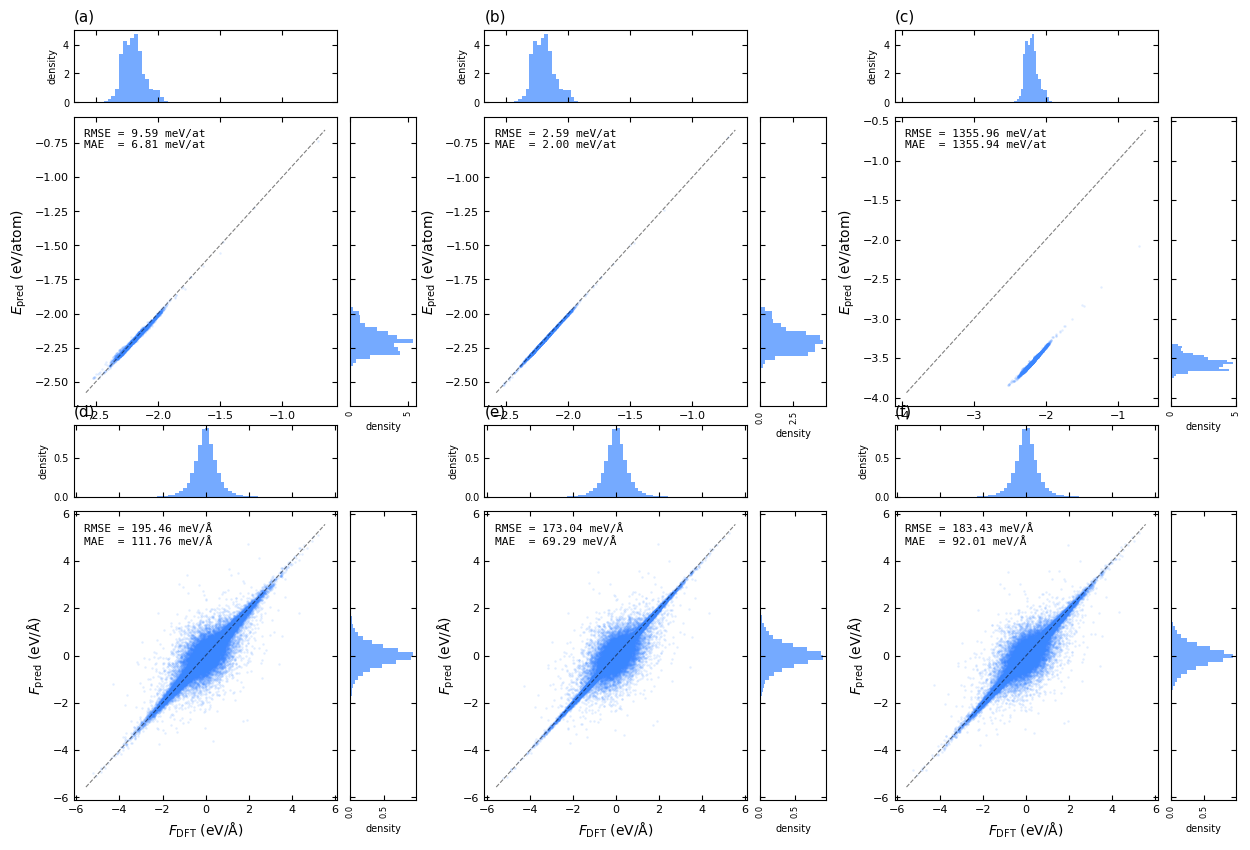

In [ ]:
BINS  = 60
COLOR = "#3a86ff"

panel_letters = [["(a)", "(b)", "(c)"], ["(d)", "(e)", "(f)"]]


def joint_panel(fig, subplot_spec, x, y, xlabel, ylabel, letter, model_label, unit, scale):
    """Scatter + top/right marginal density histograms, all axes fully framed."""
    inner = GridSpecFromSubplotSpec(
        2, 2, subplot_spec=subplot_spec,
        height_ratios=[1, 4], width_ratios=[4, 1],
        hspace=0.08, wspace=0.08,
    )
    ax_s = fig.add_subplot(inner[1, 0])               # main scatter
    ax_t = fig.add_subplot(inner[0, 0], sharex=ax_s)  # top marginal
    ax_r = fig.add_subplot(inner[1, 1], sharey=ax_s)  # right marginal

    # ── scatter + diagonal ────────────────────────────────────────────────
    ax_s.scatter(x, y, s=3, alpha=0.15, color=COLOR, rasterized=True, linewidths=0)
    lo = min(x.min(), y.min());  hi = max(x.max(), y.max())
    pad = (hi - lo) * 0.03
    ax_s.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=0.8, alpha=0.5)
    ax_s.set_xlabel(xlabel, fontsize=10)
    ax_s.set_ylabel(ylabel, fontsize=10)
    ax_s.tick_params(which="both", direction="in", top=True, right=True, labelsize=8)

    # ── marginal histograms (density normalised) ──────────────────────────
    ax_t.hist(x, bins=BINS, color=COLOR, alpha=0.7, linewidth=0, density=True)
    ax_r.hist(y, bins=BINS, color=COLOR, alpha=0.7, linewidth=0, density=True,
              orientation="horizontal")

    # ── top marginal axes ─────────────────────────────────────────────────
    ax_t.tick_params(labelbottom=False, which="both",
                     direction="in", top=True, right=True, labelsize=7)
    ax_t.set_ylabel("density", fontsize=7)

    # ── right marginal axes ───────────────────────────────────────────────
    ax_r.tick_params(labelleft=False, which="both",
                     direction="in", top=True, right=True, labelsize=7)
    ax_r.set_xlabel("density", fontsize=7)
    ax_r.xaxis.set_label_position("bottom")
    ax_r.tick_params(axis="x", labelrotation=90, labelsize=6)

    # ── RMSE/MAE annotation ───────────────────────────────────────────────
    rmse = np.sqrt(np.mean((x - y) ** 2)) * scale
    mae  = np.mean(np.abs(x - y)) * scale
    ax_s.text(0.04, 0.96,
              f"RMSE = {rmse:.2f} {unit}\nMAE  = {mae:.2f} {unit}",
              transform=ax_s.transAxes, va="top", ha="left",
              fontsize=8, family="monospace")

    # ── panel letter + model label ────────────────────────────────────────
    ax_t.set_title(f"{letter}  {model_label}", loc="left", fontsize=11)

    return ax_s, ax_t, ax_r


# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
outer = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.30)

for col, (label, _, _) in enumerate(models):
    df = dfs[label]

    # Row 0 – energy
    x_e = df["dft_energy_per_atom"].values
    y_e = df["pred_energy_per_atom"].values
    m   = np.isfinite(x_e) & np.isfinite(y_e)
    ax_e, _, _ = joint_panel(fig, outer[0, col], x_e[m], y_e[m],
                xlabel=r"$E_\mathrm{DFT}$ (eV/atom)",
                ylabel=r"$E_\mathrm{pred}$ (eV/atom)",
                letter=panel_letters[0][col], model_label=label,
                unit="meV/at", scale=1000)
    if col > 0:
        ax_e.set_ylabel("")
    ax_e.set_xlabel("")   # no x label on row 0

    # Row 1 – forces
    x_f = forces[label]["dft"]
    y_f = forces[label]["pred"]
    m   = np.isfinite(x_f) & np.isfinite(y_f)
    ax_f, _, _ = joint_panel(fig, outer[1, col], x_f[m], y_f[m],
                xlabel=r"$F_\mathrm{DFT}$ (eV/Å)",
                ylabel=r"$F_\mathrm{pred}$ (eV/Å)",
                letter=panel_letters[1][col], model_label=label,
                unit="meV/Å", scale=1000)
    if col > 0:
        ax_f.set_ylabel("")

plt.savefig("parity_plots.png", dpi=300, bbox_inches="tight")
plt.show()